In [3]:
import numpy as np
import pandas as pd
import glob
import os

input_folder = "C:\\Users\\kekea\\Downloads\\nfl_bdb_abai\\play_input"
output_folder = "C:\\Users\\kekea\\Downloads\\nfl_bdb_abai\\play_output"

# Get sorted list of input and output csv files to ensure order is preserved
input_files = sorted(glob.glob(os.path.join(input_folder, "*.csv")))
output_files = sorted(glob.glob(os.path.join(output_folder, "*.csv")))
input_dfs = [pd.read_csv(file) for file in input_files]
output_dfs = [pd.read_csv(file) for file in output_files]


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
import joblib

def combine_data(input_path: str, output_path: str, drop_duplicates: bool=True, return_cv: bool=False) -> pd.DataFrame:
    """
    Cleans data from a list of CSV files. Combines into a single DataFrame.
    Parameters: 
    cv_list (list): List of CSV file paths.
    combine (bool): Whether to combine all data into a single DataFrame.    
    Returns: df_combined (DataFrame): Combined cleaned DataFrame if combine is True.
    """
    # Get sorted list of input and output csv files to ensure order is preserved
    input_files = sorted(glob.glob(os.path.join(input_path, "*.csv")))
    output_files = sorted(glob.glob(os.path.join(output_path, "*.csv")))

    # Load and concatenate input files (vertically)
    df_inputs = pd.concat([pd.read_csv(f) for f in input_files], axis=0, ignore_index=True)

    # Load and concatenate output files (vertically)
    df_outputs = pd.concat([pd.read_csv(f) for f in output_files], axis=0, ignore_index=True)
    # Change output column names to avoid conflicts x, y -> x', y'
    df_outputs = df_outputs.rename(columns={'x': "x'", 'y': "y'"})
    
    # Combine input and output dataframes column-wise (axis=1)
    df_combined = pd.concat([df_inputs, df_outputs], axis=1)
    
    # Drop NaN rows
    df_combined = df_combined.dropna().reset_index(drop=True)
    
    # Optionally drop duplicates
    if drop_duplicates:
        df_combined = df_combined.drop_duplicates().reset_index(drop=True)

    return df_combined, df_inputs, df_outputs

def cleaned_data(df: pd.DataFrame, 
                 columns: list) -> pd.DataFrame:
    """ 
    Just returns data frame with positions x, y, x', y' and given columns
    Parameters:
    df (DataFrame): The input DataFrame.
    columns (list): List of columns to include in the returned DataFrame.
    e.g., ['game_id', 'play_id', 'player_to_predict', 'nfl_id', 'frame_id', 'play_direction', 
    'absolute_yardline_number', 'player_name', 'player_height', 'player_weight', 'player_birth_date', 
    'player_position', 'player_side', 'player_role', 'x', 'y', 's', 'a', 'dir', 'o', 'num_frames_output', 
    'ball_land_x', 'ball_land_y']
    Returns:
    DataFrame: A DataFrame containing only the specified columns.
    """
    selected_columns = ['x', 'y', "x'", "y'"] + columns
    cleaned_df = df[selected_columns].copy()
    return cleaned_df

def normalize_data(df: pd.DataFrame, columns_to_normalize: list) -> tuple: 
    """
    Normalizes specified columns in the DataFrame using min-max scaling.
    Parameters:
    df (DataFrame): The input DataFrame.
    columns_to_normalize (list): List of column names to normalize.
    Returns:
    tuple: Normalized feature and target DataFrames, and the fitted scalers.
    x_scaler, y_scaler
    DataFrame: A DataFrame with normalized columns.
    """
    df_normalized = df.copy()

    # Identify features and target
    X = df_normalized[['x', 'y'] + columns_to_normalize]
    Y = df_normalized[["x'", "y'"]]

    #normalize data
    xscaler = MinMaxScaler()
    yscaler = MinMaxScaler()

    x_norm = xscaler.fit_transform(X)
    y_norm = yscaler.fit_transform(Y)
    #x_norm = pd.DataFrame(x_norm, columns=['x', 'y'] + columns_to_normalize)
    #y_norm = pd.DataFrame(y_norm, columns=["x'", "y'"])
    joblib.dump(xscaler, 'xscaler.save')
    joblib.dump(yscaler, 'yscaler.save')
    return x_norm, y_norm, xscaler, yscaler

def data_split(x_norm: pd.DataFrame, y_norm: pd.DataFrame, test_size: float=0.2) -> tuple:
    """
    Splits DataFrame into training and testing sets.
    Parameters:
    df (DataFrame): The DataFrame to split.
    test_size (float): Proportion of the dataset to include in the test split.
    random_state (int): Random seed for reproducibility.
    Returns: X_train, X_test, Y_train, Y_test
    4 DataFrames corresponding to training and testing sets.
    """
    X_train, X_test, Y_train, Y_test = train_test_split(x_norm, y_norm, test_size=test_size, random_state=42)
    return X_train, X_test, Y_train, Y_test

In [32]:
df_combined

,game_id,play_id,player_to_predict,nfl_id,frame_id,play_direction,absolute_yardline_number,player_name,player_height,player_weight,...,o,num_frames_output,ball_land_x,ball_land_y,game_id,play_id,nfl_id,frame_id,x',y'
0,2023090700,101,False,54527,1,right,42,Bryan Cook,6-1,210,...,238.24,21,63.259998,-0.22,2.023091e+09,101.0,46137.0,1.0,56.22,17.28
1,2023090700,101,False,54527,2,right,42,Bryan Cook,6-1,210,...,236.05,21,63.259998,-0.22,2.023091e+09,101.0,46137.0,2.0,56.63,16.88
2,2023090700,101,False,54527,3,right,42,Bryan Cook,6-1,210,...,240.60,21,63.259998,-0.22,2.023091e+09,101.0,46137.0,3.0,57.06,16.46
3,2023090700,101,False,54527,4,right,42,Bryan Cook,6-1,210,...,244.25,21,63.259998,-0.22,2.023091e+09,101.0,46137.0,4.0,57.48,16.02
4,2023090700,101,False,54527,5,right,42,Bryan Cook,6-1,210,...,244.25,21,63.259998,-0.22,2.023091e+09,101.0,46137.0,5.0,57.91,15.56
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562931,2023091801,1539,False,46698,15,right,17,Levi Wallace,6-0,179,...,165.27,10,20.510000,7.39,2.024011e+09,4018.0,52457.0,14.0,30.99,10.51
562932,2023091801,1539,False,46698,16,right,17,Levi Wallace,6-0,179,...,166.18,10,20.510000,7.39,2.024011e+09,4018.0,52457.0,15.0,30.78,9.73
562933,2023091801,1539,False,46698,17,right,17,Levi Wallace,6-0,179,...,165.36,10,20.510000,7.39,2.024011e+09,4018.0,52457.0,16.0,30.63,8.93
562934,2023091801,1539,False,46698,18,right,17,Levi Wallace,6-0,179,...,166.57,10,20.510000,7.39,2.024011e+09,4018.0,52457.0,17.0,30.52,8.12


In [18]:
df_combined, df_inputs, df_outputs = combine_data(input_folder, output_folder)
cleaned_df = cleaned_data(df_combined, columns=[
    'player_side', 's', 'a', 'dir', 'o'
])
x_norm, y_norm, xscaler, yscaler = normalize_data(cleaned_df, columns_to_normalize=[
     's', 'a', 'dir', 'o'
])
X_train, X_test, Y_train, Y_test = data_split(x_norm, y_norm, test_size=0.2)

Epoch 1/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0543 - val_loss: 0.0540
Epoch 2/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0537 - val_loss: 0.0536
Epoch 3/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 4/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 17s 3ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 5/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 11s 2ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 6/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 7/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 10s 2ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 8/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 9/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 10/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0536 - val_loss: 0.0535
Epoch 11/20
6334/6334 ━━━━━━━━━━━━━━━━━━━━ 9s 1ms/step - loss: 0.0536 - val_loss: 0.0536
Epoch 12/20
6334/6334 ━━

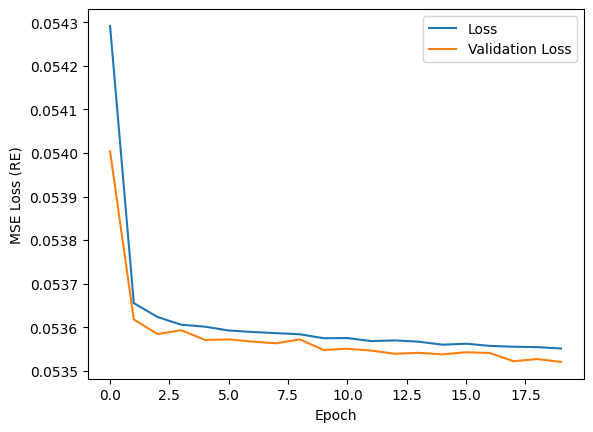

In [31]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
#import seaborn as sns

model = keras.models.Sequential([
    #keras.layers.Input(shape = (None,)),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(2, activation = 'linear')])

model.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate = 0.05), loss='mean_squared_error')
history = model.fit(X_train, Y_train,
                    batch_size=64,
                    epochs=20,
                    validation_split=0.1)

xscaler.inverse_transform(x_norm)
yscaler.inverse_transform(y_norm)

y_train = model.predict(X_train)
y_train = yscaler.inverse_transform(y_train)
Y_train = yscaler.inverse_transform(Y_train)
print(np.mean((y_train-Y_train)**2))

plt.plot(history.history['loss'], label='Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('MSE Loss (RE)')

model.save('zero_cost_model.keras')


In [30]:
Y_train

array([[0.47479513, 0.38303053],
       [0.48936346, 0.74882937],
       [0.74505422, 0.24068178],
       ...,
       [0.25279364, 0.20453268],
       [0.52777088, 0.91365424],
       [0.68181442, 0.70181682]], shape=(450348, 2))

In [36]:
"""Model simulation and visualization loads model makes x',y' prediction array
FAKE DATA: [52.33, 36.94, Defense, 0.09, 0.39, 322.4, 238.24]
"""
FAKE_DATA=  pd.DataFrame(np.array([52.33, 36.94, Defense, 0.09, 0.39, 322.4, 238.24]),
                         columns=['x', 'y', 'player_side', 's', 'a', 'dir', 'o'])

def simulate_model_prediction(model_file: str, df_input: pd.DataFrame) -> np.ndarray:
    #loads model makes r prediction array
    model_file = tf.keras.models.load_model(model_file)   
    xy_predict = model_file.predict(df_input)  # Make prediction
    return xy_predict

simulate_model_prediction('zero_cost_model.keras', FAKE_DATA)

NameError: name 'Defense' is not defined